# Decision 4: Portfolio Construction under Physical Climate Risk Vendor Uncertainty

**Decision**: A portfolio manager applies a climate-risk-based exclusion rule — issuers ranked in the top X% riskiest by flood damage ratio are excluded (zero weight). The question: how much does vendor model choice affect *which* issuers are excluded?

**Mechanism**: Damage ratio → percentile rank → exclusion decision. The key discontinuity: a small vendor difference in damage estimates can push an issuer across the rank threshold, flipping it from included to excluded.

Two thresholds are compared: **τ = 90%** (exclude top 10%) and **τ = 80%** (exclude top 20%).

In [131]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})

BLUE, RED, GREY, AMBER = '#4878CF', '#E84D0E', '#888888', '#F0A500'

In [177]:
# =============================================================================
# PARAMETERS — edit this cell only
# =============================================================================

# --- Seeds ---
VENDOR_SEED    = 1       # single-vendor display
PORTFOLIO_SEED = 42

# --- Simulation ---
N_DRAWS = 1000           # vendor uncertainty simulation
N_PAIR  = 1000            # vendor draws used for pairwise analysis (C(100,2) = 4950 pairs)

# --- Investable universe ---
N_ISSUERS = 100          # one per CFRF property

# --- Benchmark weights ---
WEIGHT_MODE     = 'equal'    # 'equal' or 'heterogeneous'
WEIGHT_LN_MU    = 0.0
WEIGHT_LN_SIGMA = 0.8

# --- Portfolio rule ---
RULE = 'exclusion'       # flagged issuers receive weight 0; remainder renormalised

# --- Rank thresholds ---
# Issuers at or above these percentile ranks are excluded (top X% riskiest)
THRESHOLDS = [0.95, 0.90]

# --- Data ---
DATA_PATH = '../../data/raw/cfrf_garp_defended_flood.csv'

In [179]:
# =============================================================================
# DATA LOADING AND TRIANGULAR DISTRIBUTION FITTING
# =============================================================================

df = pd.read_csv(DATA_PATH)
df.rename(columns={'minimim_dr': 'minimum_dr'}, inplace=True)
df = df.dropna(subset=['property_rank']).reset_index(drop=True)
df['property_rank'] = df['property_rank'].astype(int)
n = len(df)

assert n == N_ISSUERS, (
    f"N_ISSUERS={N_ISSUERS} but data has {n} properties — adjust N_ISSUERS in PARAMETERS cell."
)

# Triangular distribution parameters
# mode c = 3*mean - min - max, clipped to [min, max]
tri_a = df['minimum_dr'].values.astype(float)
tri_b = df['maximum_dr'].values.astype(float)
tri_c = np.clip(3.0 * df['mean_dr'].values - tri_a - tri_b, tri_a, tri_b)

results = pd.DataFrame({
    'property_rank': df['property_rank'],
    'd_min':  tri_a,
    'd_mean': df['mean_dr'].values,
    'd_max':  tri_b,
    'd_mode': tri_c,
})

zero_mask = (tri_b == 0)
print(f"Properties loaded: {n}")
print(f"Zero-damage (d=0 always): {zero_mask.sum()}")
print(f"Non-zero damage (fitted triangular): {(~zero_mask).sum()}")


def triangular_sample(rng, a, b, c):
    """Draw one sample per property from Triangular(a, c, b) using inverse CDF.
    Properties with a==b are treated as point masses at a (zero-damage assets).
    """
    u    = rng.uniform(size=len(a))
    span = np.where(b > a, b - a, 1.0)
    fc   = np.where(b > a, (c - a) / span, 0.0)
    left  = a + np.sqrt(np.maximum(u, 0)     * span * np.maximum(c - a, 0))
    right = b - np.sqrt(np.maximum(1 - u, 0) * span * np.maximum(b - c, 0))
    x = np.where(u <= fc, left, right)
    return np.where(b > a, np.clip(x, 0, 1), a)

Properties loaded: 100
Zero-damage (d=0 always): 20
Non-zero damage (fitted triangular): 80


In [181]:
# =============================================================================
# BENCHMARK WEIGHT CONSTRUCTION
# =============================================================================

rng_portfolio = np.random.default_rng(PORTFOLIO_SEED)

if WEIGHT_MODE == 'equal':
    w_bench = np.ones(N_ISSUERS) / N_ISSUERS
elif WEIGHT_MODE == 'heterogeneous':
    raw = rng_portfolio.lognormal(
        mean=WEIGHT_LN_MU, sigma=WEIGHT_LN_SIGMA, size=N_ISSUERS
    )
    w_bench = raw / raw.sum()

print(f"Weight mode: {WEIGHT_MODE}")
print(f"Total benchmark weight: {w_bench.sum():.6f}  (should be 1.0)")

Weight mode: equal
Total benchmark weight: 1.000000  (should be 1.0)


In [183]:
# =============================================================================
# CORE FUNCTIONS
# =============================================================================

def sample_damage(rng):
    """Draw one damage ratio per issuer from the fitted triangular distributions."""
    return triangular_sample(rng, tri_a, tri_b, tri_c)


def rank_issuers(d_array):
    """Convert damage ratios to percentile ranks within the universe.
    0 = least risky, approaching 1 = most risky. Average ranking handles ties.
    """
    return stats.rankdata(d_array, method='average') / N_ISSUERS


def apply_exclusion(w_b, r, threshold):
    """Exclude issuers with rank >= threshold (weight set to 0).
    Freed weight is redistributed pro-rata to remaining issuers.

    Returns
    -------
    w_active : portfolio weights after exclusion (sums to 1)
    x        : active weight deviations = w_active - w_b (sums to 0)
    """
    w_active = w_b.copy()
    flagged  = r >= threshold

    weight_freed          = w_active[flagged].sum()
    w_active[flagged]     = 0.0

    unflagged = ~flagged
    if unflagged.sum() > 0 and weight_freed > 0:
        total_unflagged = w_active[unflagged].sum()
        if total_unflagged > 0:
            w_active[unflagged] += weight_freed * (w_active[unflagged] / total_unflagged)

    w_active = w_active / w_active.sum()
    return w_active, w_active - w_b

## Figure 1: Single vendor draw — ordered damage ratios with exclusion thresholds

One vendor's damage ratio estimates for all 100 properties, sorted from lowest to highest risk. Vertical dashed lines mark the two exclusion thresholds (τ = 80% and τ = 90%).

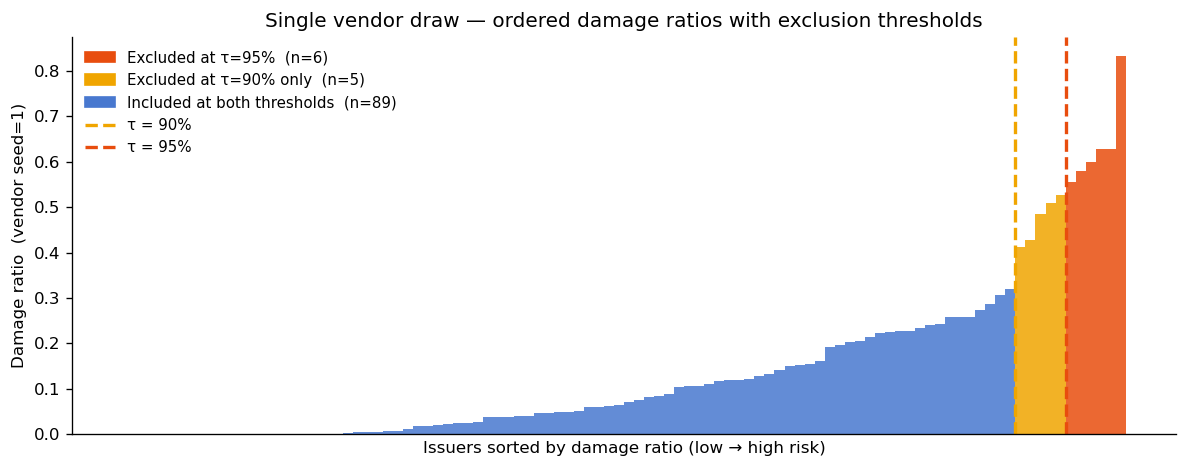

In [194]:
# =============================================================================
# FIGURE 1 — SINGLE VENDOR: ORDERED DAMAGE RATIOS WITH EXCLUSION THRESHOLDS
# =============================================================================

rng_vendor = np.random.default_rng(VENDOR_SEED)
d_v = sample_damage(rng_vendor)
r_v = rank_issuers(d_v)

sort_idx = np.argsort(d_v)
d_sorted = d_v[sort_idx]
r_sorted = r_v[sort_idx]

tau_hi = max(THRESHOLDS)   # 0.90
tau_lo = min(THRESHOLDS)   # 0.80

# Colour bars by exclusion zone
bar_colours = np.where(
    r_sorted >= tau_hi, RED,
    np.where(r_sorted >= tau_lo, AMBER, BLUE)
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(np.arange(N_ISSUERS), d_sorted, color=bar_colours, width=1.0, alpha=0.85)

for tau, col in [(tau_lo, AMBER), (tau_hi, RED)]:
    ax.axvline(tau * N_ISSUERS-1.5, color=col, linewidth=2.0, linestyle='--')

ax.set_xlabel('Issuers sorted by damage ratio (low \u2192 high risk)')
ax.set_ylabel(f'Damage ratio  (vendor seed={VENDOR_SEED})')
ax.set_title('Single vendor draw \u2014 ordered damage ratios with exclusion thresholds')
ax.set_xticks([])
ax.legend(handles=[
    mpatches.Patch(color=RED,   label=f'Excluded at \u03c4={tau_hi:.0%}  (n={(r_v >= tau_hi).sum()})'),
    mpatches.Patch(color=AMBER, label=f'Excluded at \u03c4={tau_lo:.0%} only  '
                                      f'(n={((r_v >= tau_lo) & (r_v < tau_hi)).sum()})'),
    mpatches.Patch(color=BLUE,  label=f'Included at both thresholds  (n={(r_v < tau_lo).sum()})'),
    plt.Line2D([0], [0], color=AMBER, lw=2, ls='--', label=f'\u03c4 = {tau_lo:.0%}'),
    plt.Line2D([0], [0], color=RED,   lw=2, ls='--', label=f'\u03c4 = {tau_hi:.0%}'),
], frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

## Simulation: N vendor draws per threshold

For each threshold, simulate N_DRAWS independent vendor draws. An issuer is **ambiguous** if the exclusion decision is vendor-dependent (flagged in some draws but not others).

In [169]:
# =============================================================================
# SIMULATION — N_DRAWS vendor draws for each threshold
# =============================================================================

sim_results = {}

for tau in THRESHOLDS:
    rng_sim = np.random.default_rng(PORTFOLIO_SEED + 100)  # same seed per threshold for comparability
    flagged_matrix_t = np.zeros((N_DRAWS, N_ISSUERS), dtype=bool)

    for k in range(N_DRAWS):
        d_k = sample_damage(rng_sim)
        r_k = rank_issuers(d_k)
        flagged_matrix_t[k] = r_k >= tau

    inc_prob  = flagged_matrix_t.mean(axis=0)
    always_f  = inc_prob == 1.0
    never_f   = inc_prob == 0.0
    ambiguous = (~always_f) & (~never_f)

    sim_results[tau] = {
        'flagged_matrix': flagged_matrix_t,
        'inclusion_prob': inc_prob,
        'always_flagged': always_f,
        'never_flagged':  never_f,
        'ambiguous':      ambiguous,
    }

# Vendor-uncertain (ambiguous) properties per threshold
print(f"Vendor-uncertain exclusion decisions  ({N_DRAWS} draws)\n")
print(f"  {'Threshold':<12}  {'Always excl.':>14}  {'Never excl.':>12}  "
      f"{'Ambiguous':>11}  {'Ambiguity rate':>14}")
print("  " + "-" * 68)
for tau in THRESHOLDS:
    r = sim_results[tau]
    print(f"  \u03c4 = {tau:.0%}         "
          f"  {r['always_flagged'].sum():>14}  "
          f"  {r['never_flagged'].sum():>12}  "
          f"  {r['ambiguous'].sum():>11}  "
          f"  {r['ambiguous'].mean()*100:>13.1f}%")

Vendor-uncertain exclusion decisions  (1000 draws)

  Threshold       Always excl.   Never excl.    Ambiguous  Ambiguity rate
  --------------------------------------------------------------------
  τ = 90%                        0              54             46             46.0%
  τ = 80%                        1              43             56             56.0%


## Figure 2: Ambiguous zone — exclusion probability across vendor draws

Each bar is one issuer (sorted by CFRF mean damage ratio). Bar height = fraction of vendor draws that flag the issuer for exclusion. **Amber bars** are the ambiguous zone: issuers where vendor choice determines whether they are excluded.

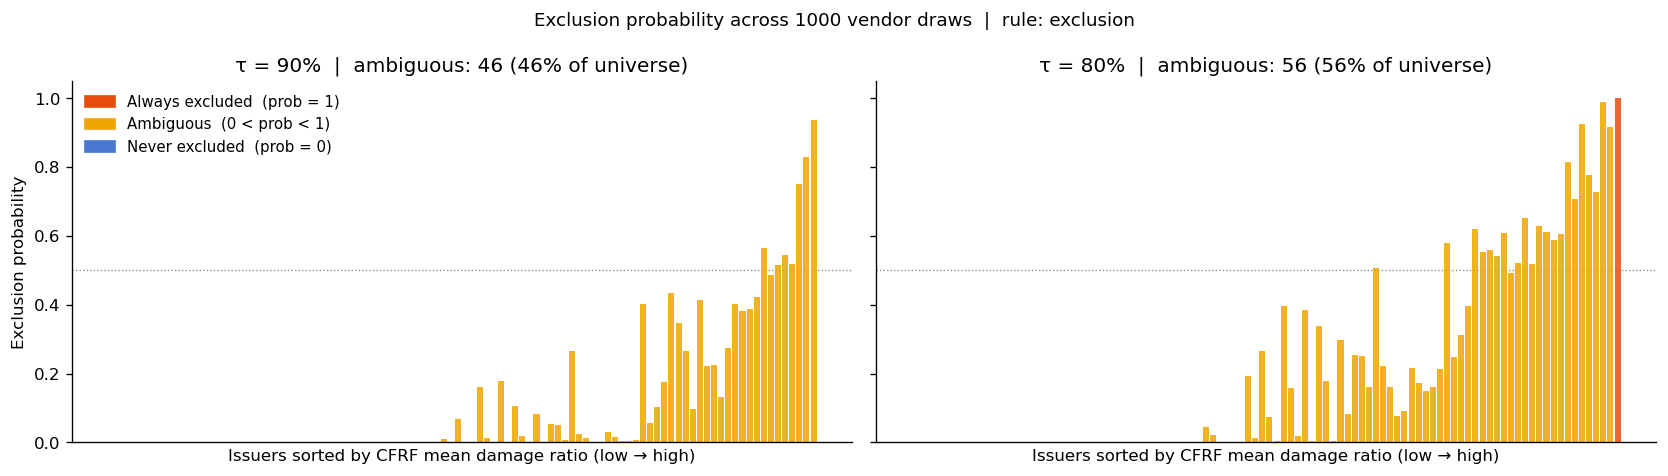

In [172]:
# =============================================================================
# FIGURE 2 — AMBIGUOUS ZONE: EXCLUSION PROBABILITY PER THRESHOLD
# =============================================================================

mean_d        = results['d_mean'].values
sort_idx_mean = np.argsort(mean_d)
x_pos         = np.arange(N_ISSUERS)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

for ax, tau in zip(axes, [max(THRESHOLDS), min(THRESHOLDS)]):
    r             = sim_results[tau]
    prob_sorted   = r['inclusion_prob'][sort_idx_mean]
    ambi_sorted   = r['ambiguous'][sort_idx_mean]
    always_sorted = r['always_flagged'][sort_idx_mean]

    bar_col = np.where(always_sorted, RED, np.where(ambi_sorted, AMBER, BLUE))
    ax.bar(x_pos, prob_sorted, color=bar_col, width=0.85, alpha=0.85)
    ax.axhline(0.5, color=GREY, lw=0.8, ls=':', zorder=0)
    ax.set_xticks([])
    ax.set_xlabel('Issuers sorted by CFRF mean damage ratio (low \u2192 high)')
    ax.set_title(
        f'\u03c4 = {tau:.0%}  |  ambiguous: {r["ambiguous"].sum()} '
        f'({r["ambiguous"].mean()*100:.0f}% of universe)'
    )

axes[0].set_ylabel('Exclusion probability')
axes[0].legend(handles=[
    mpatches.Patch(color=RED,   label='Always excluded  (prob = 1)'),
    mpatches.Patch(color=AMBER, label='Ambiguous  (0 < prob < 1)'),
    mpatches.Patch(color=BLUE,  label='Never excluded  (prob = 0)'),
], frameon=False, fontsize=9)

plt.suptitle(
    f'Exclusion probability across {N_DRAWS} vendor draws  |  rule: {RULE}',
    fontsize=11
)
plt.tight_layout()
plt.show()

## Figure 3: Pairwise vendor disagreement distributions

For every pair of vendor draws (C(100,2) = 4,950 pairs), compute the fraction of issuers in each agreement category. Distributions show how often two vendors agree vs. disagree on exclusion decisions, across both thresholds.

Pairwise disagreement summary  (499,500 vendor pairs from 1000 draws)

  Threshold    Both excl. (med)   Disagree (med)   Neither excl. (med)
  --------------------------------------------------------------------
  τ = 90%                    5.0%              12.0%                   83.0%
  τ = 80%                   12.0%              18.0%                   70.0%


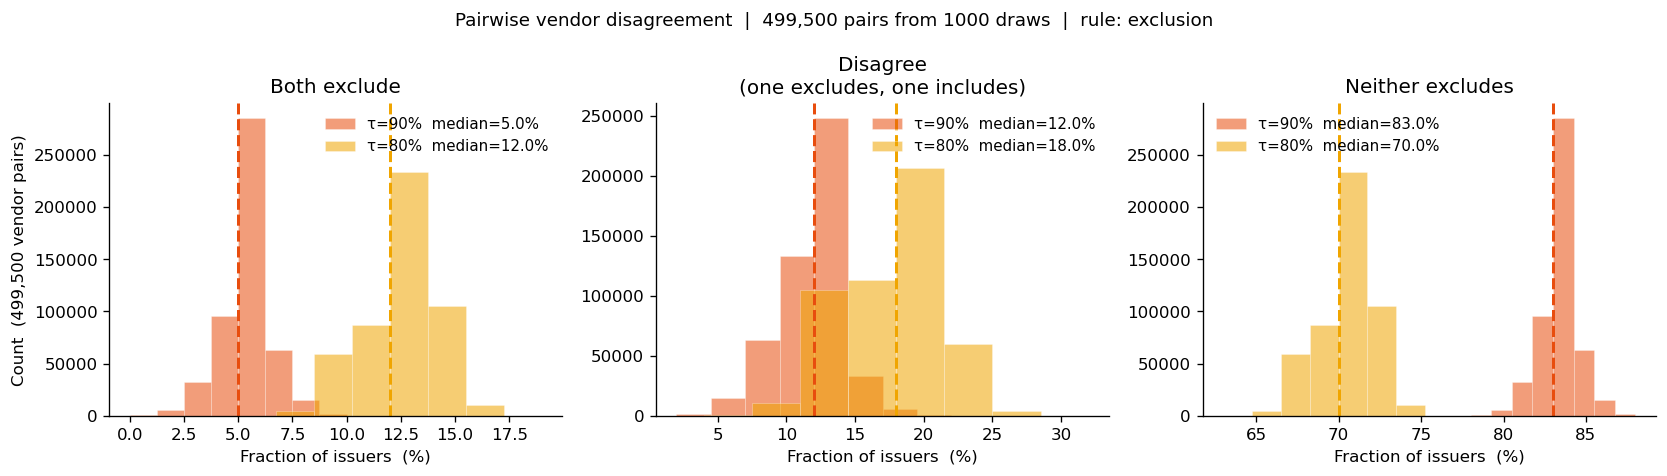

In [175]:
# =============================================================================
# PAIRWISE VENDOR DISAGREEMENT — C(N_PAIR, 2) pairs per threshold
# =============================================================================

ii, jj  = np.triu_indices(N_PAIR, k=1)
n_pairs = len(ii)

pair_results = {}
for tau in THRESHOLDS:
    fp      = sim_results[tau]['flagged_matrix'][:N_PAIR]   # (N_PAIR, N_ISSUERS)
    fp_i, fp_j = fp[ii], fp[jj]
    pair_results[tau] = {
        'both_flag':    (fp_i  & fp_j).mean(axis=1),
        'disagree':     (fp_i  ^ fp_j).mean(axis=1),
        'neither_flag': (~fp_i & ~fp_j).mean(axis=1),
    }

# Summary table
print(f"Pairwise disagreement summary  ({n_pairs:,} vendor pairs from {N_PAIR} draws)\n")
print(f"  {'Threshold':<10}  {'Both excl. (med)':>17}  {'Disagree (med)':>15}  {'Neither excl. (med)':>20}")
print("  " + "-" * 68)
for tau in THRESHOLDS:
    p = pair_results[tau]
    print(f"  \u03c4 = {tau:.0%}     "
          f"  {np.median(p['both_flag'])*100:>16.1f}%  "
          f"  {np.median(p['disagree'])*100:>14.1f}%  "
          f"  {np.median(p['neither_flag'])*100:>19.1f}%")

# =============================================================================
# FIGURE 3 — DISTRIBUTIONS OF AGREEMENT / DISAGREEMENT ACROSS VENDOR PAIRS
# =============================================================================

categories = [
    ('both_flag',    'Both exclude'),
    ('disagree',     'Disagree\n(one excludes, one includes)'),
    ('neither_flag', 'Neither excludes'),
]
thresh_colours = {max(THRESHOLDS): RED, min(THRESHOLDS): AMBER}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (key, title) in zip(axes, categories):
    for tau in sorted(THRESHOLDS, reverse=True):
        data = pair_results[tau][key] * 100
        med  = np.median(data)
        col  = thresh_colours[tau]
        ax.hist(data, bins=8, color=col, alpha=0.55,
                edgecolor='white', linewidth=0.3,
                label=f'\u03c4={tau:.0%}  median={med:.1f}%')
        ax.axvline(med, color=col, linewidth=1.8, linestyle='--')
    ax.set_title(title)
    ax.set_xlabel('Fraction of issuers  (%)')
    ax.legend(frameon=False, fontsize=9)

axes[0].set_ylabel(f'Count  ({n_pairs:,} vendor pairs)')

plt.suptitle(
    f'Pairwise vendor disagreement  |  {n_pairs:,} pairs from {N_PAIR} draws  |  rule: {RULE}',
    fontsize=11
)
plt.tight_layout()
plt.show()